# Collaborative Filtering

## Task Objective

This task compares two collaborative filtering approaches:

1. **Memory-based Collaborative Filtering**
2. **Model-based Collaborative Filtering using Matrix Factorization**

Both approaches will be trained and evaluated using the same user-item interaction dataset and evaluation protocol.

The goal is not only to compare their performance, but also to understand how their different approaches to learning user preferences affect their recommendations.

## 1. Dataset Selection

We use the MovieLens 1M dataset, which contains explicit ratings given by users to movies.

The dataset was chosen after considering multiple MovieLens versions as well as the HetRec dataset. MovieLens 1M provides a large interaction dataset while keeping the comparison between memory-based collaborative filtering and matrix factorization relatively clean and computationally manageable.

The dataset contains ratings on a 1–5 scale, which makes it suitable for evaluating rating prediction using metrics such as RMSE and MAE.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
import zipfile
import requests
from io import BytesIO

url = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"

response = requests.get(url)
response.raise_for_status()

with zipfile.ZipFile(BytesIO(response.content)) as z:
    z.extractall(".")

print("Dataset downloaded and extracted.")

Dataset downloaded and extracted.


In [20]:
ratings_path = "ml-1m/ratings.dat"

ratings = pd.read_csv(
    ratings_path,
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

ratings

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [21]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [22]:
print("Shape:", ratings.shape)
print("\nData types:")
print(ratings.dtypes)
print("\nMissing values:")
print(ratings.isnull().sum())

Shape: (1000209, 4)

Data types:
user_id      int64
movie_id     int64
rating       int64
timestamp    int64
dtype: object

Missing values:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64


In [23]:
print("Unique users:", ratings["user_id"].nunique())
print("Unique movies:", ratings["movie_id"].nunique())
print("Number of ratings:", len(ratings))
print("Rating range:", ratings["rating"].min(), "to", ratings["rating"].max())

Unique users: 6040
Unique movies: 3706
Number of ratings: 1000209
Rating range: 1 to 5


In [24]:
num_users = ratings["user_id"].nunique()
num_movies = ratings["movie_id"].nunique()
num_ratings = len(ratings)

total_possible = num_users * num_movies
density = num_ratings / total_possible
sparsity = 1 - density

print(f"Density: {density:.4%}")
print(f"Sparsity: {sparsity:.4%}")

Density: 4.4684%
Sparsity: 95.5316%


In [25]:
user_rating_counts = ratings.groupby("user_id").size()
movie_rating_counts = ratings.groupby("movie_id").size()

print("Average ratings per user:", user_rating_counts.mean())
print("Median ratings per user:", user_rating_counts.median())
print("Minimum ratings by a user:", user_rating_counts.min())
print("Maximum ratings by a user:", user_rating_counts.max())

print("\nAverage ratings per movie:", movie_rating_counts.mean())
print("Median ratings per movie:", movie_rating_counts.median())
print("Minimum ratings for a movie:", movie_rating_counts.min())
print("Maximum ratings for a movie:", movie_rating_counts.max())

Average ratings per user: 165.5975165562914
Median ratings per user: 96.0
Minimum ratings by a user: 20
Maximum ratings by a user: 2314

Average ratings per movie: 269.88909875876953
Median ratings per movie: 123.5
Minimum ratings for a movie: 1
Maximum ratings for a movie: 3428


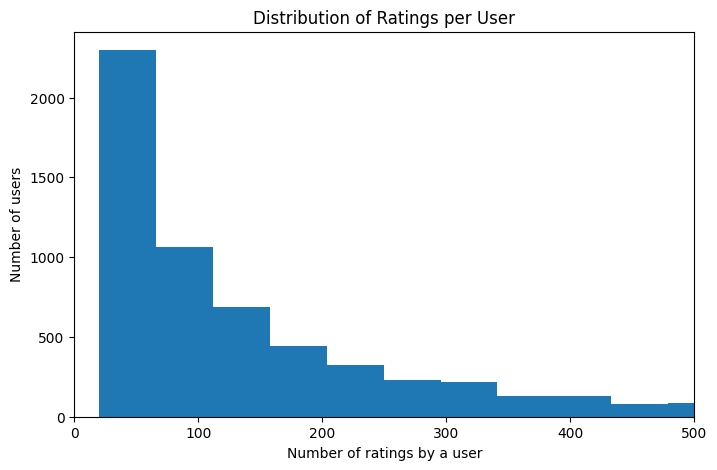

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(user_rating_counts, bins=50)

plt.xlim(0, 500)

plt.xlabel("Number of ratings by a user")
plt.ylabel("Number of users")
plt.title("Distribution of Ratings per User")

plt.show()

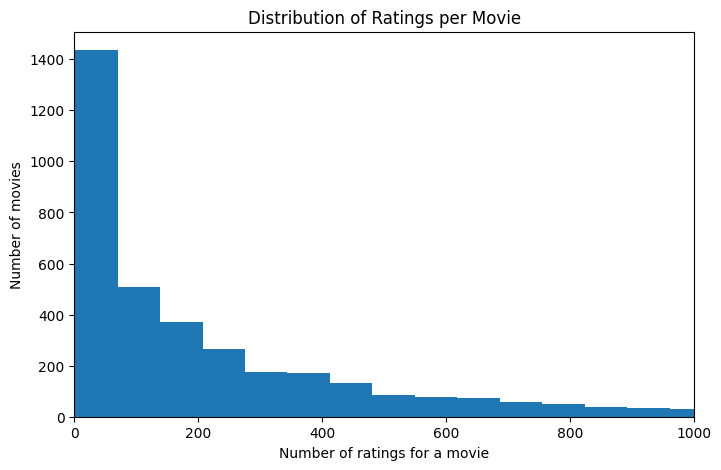

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(movie_rating_counts, bins=50)

plt.xlim(0, 1000)

plt.xlabel("Number of ratings for a movie")
plt.ylabel("Number of movies")
plt.title("Distribution of Ratings per Movie")

plt.show()

### EDA Observation

The number of ratings is highly right-skewed for both users and
movies. Most users and movies have relatively few interactions,
while a smaller number account for a large number of ratings.

Earlier we discovered that the sparsity was around 95.5% so this graph is
basically proving that fact right (Uneven distribution of interactions)


In [28]:
rating_counts = ratings["rating"].value_counts().sort_index()

print(rating_counts)

rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64


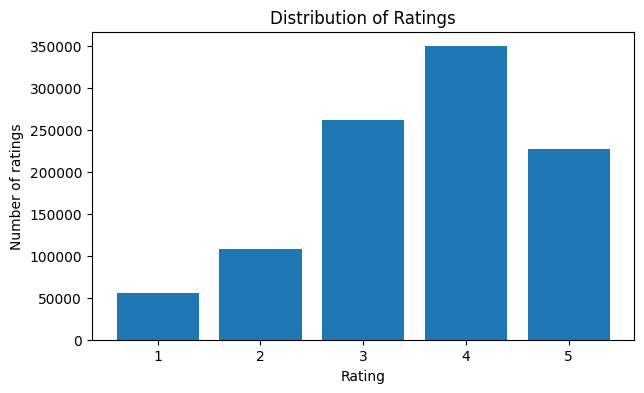

In [29]:
plt.figure(figsize=(7, 4))

plt.bar(rating_counts.index, rating_counts.values)

plt.xlabel("Rating")
plt.ylabel("Number of ratings")
plt.title("Distribution of Ratings")

plt.show()

The ratings are distributed across the 1–5 scale, but the
distribution is not necessarily uniform. Its important to understand this because a model that predicts values close to the most common ratings might
get a higher error. It matters here because here the model cant learn the extremes individual user preferences.

## 2. Preprocessing and Evaluation Setup

We use an 80/20 train-test split for evaluation. A fixed random
seed is used so that both collaborative filtering approaches are
evaluated on exactly the same data.

The test set is kept separate and is not used during model training.

In [30]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print("Training ratings:", len(train))
print("Test ratings:", len(test))

Training ratings: 800167
Test ratings: 200042


In [31]:
print("Train users:", train["user_id"].nunique())
print("Train movies:", train["movie_id"].nunique())

print("Test users:", test["user_id"].nunique())
print("Test movies:", test["movie_id"].nunique())

Train users: 6040
Train movies: 3683
Test users: 6038
Test movies: 3444


## 3. Memory-Based Collaborative Filtering

We use user-user collaborative filtering. For each user, we find
other users with similar rating patterns and use their ratings to
predict ratings for unseen movies. (Similar to what KNNs so in
unsupervised ml)

Cosine similarity is used to measure how similar users are based
on their rating patterns. A K-nearest-neighbour approach is then
used to find the most similar users for each target user.

In [44]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(
    n_neighbors=21,
    metric="cosine"
)

knn.fit(user_item.fillna(0))

NearestNeighbors(metric='cosine', n_neighbors=21)

In [45]:
distances, neighbours = knn.kneighbors(user_item.fillna(0))

In [46]:
print(distances.shape)
print(neighbours.shape)

(6040, 21)
(6040, 21)


In [47]:
similarities = 1 - distances

In [48]:
train_matrix = user_item.fillna(0).values
user_ids = user_item.index
user_to_index = {user_id: i for i, user_id in enumerate(user_ids)}

global_mean = train["rating"].mean()

(In all fairness below implementation of KNN predicted rating taken from LLM.
Was not sure how to implement with the 20 parameters)

In [49]:
def predict_rating(user_id, movie_id, k=20):
    if user_id not in user_to_index or movie_id not in user_item.columns:
        return global_mean

    user_index = user_to_index[user_id]

    neighbour_indices = neighbours[user_index, 1:k+1]
    neighbour_similarities = similarities[user_index, 1:k+1]

    movie_index = user_item.columns.get_loc(movie_id)
    neighbour_ratings = train_matrix[neighbour_indices, movie_index]

    rated = neighbour_ratings > 0

    if rated.sum() == 0:
        return global_mean

    weighted_sum = np.sum(
        neighbour_similarities[rated] * neighbour_ratings[rated]
    )

    similarity_sum = np.sum(
        neighbour_similarities[rated]
    )

    return weighted_sum / similarity_sum

Testing on 1 rating first

In [50]:
test_user = test.iloc[0]["user_id"]
test_movie = test.iloc[0]["movie_id"]

print("Actual:", test.iloc[0]["rating"])
print("Predicted:", predict_rating(test_user, test_movie))

Actual: 2
Predicted: 2.6787496876676857


In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

predictions = []

for _, row in test.iterrows():
    prediction = predict_rating(row["user_id"], row["movie_id"])
    predictions.append(prediction)

test_actual = test["rating"].values

rmse = np.sqrt(mean_squared_error(test_actual, predictions))
mae = mean_absolute_error(test_actual, predictions)

print("Memory-Based CF RMSE:", rmse)
print("Memory-Based CF MAE:", mae)

Memory-Based CF RMSE: 1.0434008823763983
Memory-Based CF MAE: 0.819378648004979


In [53]:
baseline_prediction = train["rating"].mean()

baseline_rmse = np.sqrt(
    mean_squared_error(
        test["rating"],
        [baseline_prediction] * len(test)
    )
)

baseline_mae = mean_absolute_error(
    test["rating"],
    [baseline_prediction] * len(test)
)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)

Baseline RMSE: 1.1197293450628865
Baseline MAE: 0.9359866339219812


## 4. Model-Based Collaborative Filtering — Matrix Factorization

Matrix Factorization represents each user and movie using a
lower-dimensional vector of latent factors.

The predicted rating is calculated using the interaction between
the user and movie vectors, along with user and movie biases.

The model is trained from scratch using gradient descent.

(converting the original user and movie IDs into positions in our parameter matrice)

In [54]:
user_ids = train["user_id"].unique()
movie_ids = train["movie_id"].unique()

user_to_index = {user_id: i for i, user_id in enumerate(user_ids)}
movie_to_index = {movie_id: i for i, movie_id in enumerate(movie_ids)}

train_users = train["user_id"].map(user_to_index).values
train_movies = train["movie_id"].map(movie_to_index).values
train_ratings = train["rating"].values

To make
User 1 → [0.12, -0.03, 0.08, ...]
Movie 1 → [-0.04, 0.09, 0.13, ...]

In [55]:
num_users = len(user_ids)
num_movies = len(movie_ids)
num_factors = 20

user_factors = np.random.normal(
    0, 0.1, (num_users, num_factors)
)

movie_factors = np.random.normal(
    0, 0.1, (num_movies, num_factors)
)

user_bias = np.zeros(num_users)
movie_bias = np.zeros(num_movies)

global_mean = train["rating"].mean()

In [56]:
learning_rate = 0.005
regularization = 0.02
epochs = 15

for epoch in range(epochs):

    for u, m, r in zip(train_users, train_movies, train_ratings):

        prediction = (
            global_mean
            + user_bias[u]
            + movie_bias[m]
            + np.dot(user_factors[u], movie_factors[m])
        )

        error = r - prediction

        user_bias[u] += learning_rate * (
            error - regularization * user_bias[u]
        )

        movie_bias[m] += learning_rate * (
            error - regularization * movie_bias[m]
        )

        user_factors[u] += learning_rate * (
            error * movie_factors[m]
            - regularization * user_factors[u]
        )

        movie_factors[m] += learning_rate * (
            error * user_factors[u]
            - regularization * movie_factors[m]
        )

    print("Epoch:", epoch + 1)

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14
Epoch: 15


In [57]:
test_users = test["user_id"].map(user_to_index)
test_movies = test["movie_id"].map(movie_to_index)

predictions_mf = []

for u, m in zip(test_users, test_movies):

    if pd.isna(u) or pd.isna(m):
        predictions_mf.append(global_mean)
        continue

    u = int(u)
    m = int(m)

    prediction = (
        global_mean
        + user_bias[u]
        + movie_bias[m]
        + np.dot(user_factors[u], movie_factors[m])
    )

    predictions_mf.append(prediction)

In [58]:
rmse_mf = np.sqrt(
    mean_squared_error(test["rating"], predictions_mf)
)

mae_mf = mean_absolute_error(
    test["rating"], predictions_mf
)

print("Matrix Factorization RMSE:", rmse_mf)
print("Matrix Factorization MAE:", mae_mf)

Matrix Factorization RMSE: 0.8840057580954338
Matrix Factorization MAE: 0.6980356981736313


In [59]:
results = pd.DataFrame({
    "Method": [
        "Global Mean",
        "Memory-Based CF",
        "Matrix Factorization"
    ],
    "RMSE": [
        baseline_rmse,
        rmse,
        rmse_mf
    ],
    "MAE": [
        baseline_mae,
        mae,
        mae_mf
    ]
})

results

,Method,RMSE,MAE
0,Global Mean,1.119729,0.935987
1,Memory-Based CF,1.043401,0.819379
2,Matrix Factorization,0.884006,0.698036


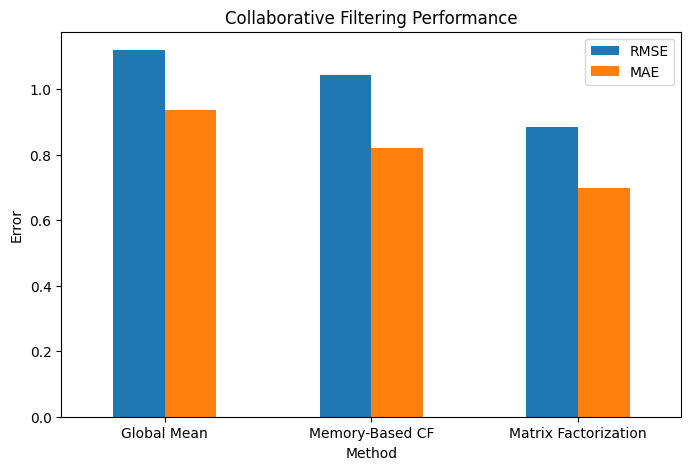

In [60]:
results.plot(
    x="Method",
    y=["RMSE", "MAE"],
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Error")
plt.title("Collaborative Filtering Performance")
plt.xticks(rotation=0)
plt.show()

## 5. Final Comparison

Matrix Factorization achieved the lowest RMSE and MAE among the
methods tested. Memory-based collaborative filtering also improved
over the global mean baseline.

The results suggest that using information from similar users is
useful, but learning latent representations of users and movies
was more effective for this dataset and evaluation setup.

The comparison is based on the same train-test split, so the
difference comes from the modelling approach rather than a change
in the evaluation data.